# 01 - The confident model that lost the company money

> The model says this house is worth \$412,000. Can the desk safely offer \$412,000?

That is the question the acquisitions desk will ask you in your first week, and it deserves a sharper phrasing before we try to answer it. The model outputs one number. The desk's risk lives in the *spread* of market prices that one number stands in for — the range of prices this house might actually fetch. What the desk needs is not a better single number; it is a range it can trust at a known error rate, and a way to know when to walk away from a deal the model cannot price.

**What you will learn**

- Why a healthy-looking MAE and R2 answer a different question than "how wrong can this one offer be"
- How to measure the hit rate of any interval recipe — and why an interval with an unmeasured hit rate is decoration
- Two homegrown interval recipes (plus-or-minus the MAE, and quantiles of training residuals), committed live, and exactly where each one fails
- The contract an honest uncertainty method has to sign — the contract notebook 02 delivers in fifteen lines

**Where we are in the series.** This is notebook 01 of 8: the problem statement. Notebook 02 introduces the fix — split conformal prediction — and everything after builds on the pair of them.

## 1. A true story: the model that bought 7,000 houses too expensively

In 2018, Zillow — the biggest real-estate site in the United States — launched Zillow Offers, an "iBuying" business. A homeowner requested a cash offer, a pricing model estimated what the home would resell for, and Zillow offered roughly that number, planning to buy, lightly renovate, and flip. The model's **point prediction** — a single estimated price with no statement of how far off it might be — was not a dashboard widget in this business. It was the business: every offer letter was a trade executed at the model's number.

In late 2021 it came apart. The market cooled, the model kept overpricing, and because the offers were systematically generous, sellers accepted them at scale — the model's worst calls were precisely the offers most likely to be signed. By November 2021 Zillow was working to offload roughly 7,000 homes it expected to sell at a loss, announced write-downs totalling more than half a billion dollars, shut the unit down entirely, and laid off about 2,000 employees — a quarter of the company. The detail that matters for us: the model was not unusually bad. Its average accuracy was competitive. What was missing was any statement, deal by deal, of how far off the single number might be — so nobody could price the risk of acting on it.

In this series you have just joined the data science team at **Hearthstone**, a (fictional) property-tech startup running the same playbook: "we predict the market price of your home and buy it from you within a week." The model prices each listing; the acquisitions desk turns that price into an offer letter. The Zillow story above is real and is the reason this series exists; everything from here on — Hearthstone, its listings, its prices — is synthetic data we generate ourselves, which buys us something no real market offers: we know the true price process, so every uncertainty claim we make can be scored exactly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

# Series palette: blue = data, green = good/covered, amber = warning/calibration,
# red = bad/naive, gray = reference/truth, purple = alternative method.
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

The cell below defines the listing simulator used throughout the series. Do not skim past it — read the docstring the way you would read a data dictionary on your first day, because its baked-in facts are the test fixtures of later notebooks. The deliberate "bigger homes, noisier prices" fact is the whole plot of notebook 05; the two-regions fact drives notebook 07.

In [2]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]

def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    What the simulator bakes in (and what we will test against later):
    - Price depends nonlinearly on size, age, distance to the center, and condition.
    - Noise is larger for bigger homes: two 60 m2 flats sell for nearly the same
      price, two 300 m2 villas do not. This heteroskedasticity is deliberate.
    - 'riverton' and 'eastvale' differ ONLY in the mix of homes on the market
      (newer, bigger, farther out in eastvale), NOT in how features map to price.
      In the language of notebook 07: pure covariate shift, identical P(price | features).

    Returns X (n x 4 array: size_m2, age_years, dist_center_km, condition_1to5)
    and y (price in thousands of dollars).
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=6.0, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=12.0, size=n)
    else:
        raise ValueError(f"Unknown region: {region}")
    condition = rng.integers(1, 6, size=n).astype(float)
    log_price = (
        10.0
        + 0.70 * np.log(size)
        - 0.004 * age
        - 0.035 * dist
        + 0.05 * condition
    )
    noise_sd = 0.10 + 0.0008 * size  # bigger homes, noisier prices - on purpose
    log_price = log_price + rng.normal(0.0, noise_sd)
    X = np.column_stack([size, age, dist, condition])
    return X, np.exp(log_price) / 1000.0

In [3]:
X_all, y_all = simulate_hearthstone_listings(n=4000, seed=RANDOM_SEED)

# 2,500 listings to build the model, 1,500 held back as stand-ins for the
# desk's future deals. The test listings stay untouched until scoring time.
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=1500, random_state=RANDOM_SEED
)

listings = pd.DataFrame(X_all, columns=FEATURE_NAMES)
listings["price_k"] = y_all

print(f"Simulated {len(y_all):,} riverton listings; prices in thousands of dollars.")
print(f"Model-building listings: {len(y_train):,} | held-back test listings: {len(y_test):,}")
print(
    f"Market prices: mean ${y_all.mean():,.0f}k, min ${y_all.min():,.0f}k, "
    f"max ${y_all.max():,.0f}k"
)
listings.head().round(1)

Simulated 4,000 riverton listings; prices in thousands of dollars.
Model-building listings: 2,500 | held-back test listings: 1,500
Market prices: mean $641k, min $117k, max $2,434k


,size_m2,age_years,dist_center_km,condition_1to5,price_k
0,184.5,52.2,8.8,4.0,552.2
1,185.2,23.8,1.0,1.0,764.6
2,67.2,23.9,6.1,1.0,330.8
3,131.2,47.8,6.5,5.0,628.8
4,134.0,20.2,3.3,4.0,681.8


Read the first row aloud, the way the desk would:

> 184.5 m2, 52 years old, 8.8 km from the center, condition 4 out of 5 — the market said \$552k.

Each row is one closed sale: four facts about the home in the `FEATURE_NAMES` columns, and `price_k`, the price the market actually paid, in thousands of dollars. Prices run from \$117k to \$2,434k around a mean of \$641k, so this is a market with real spread in it. Notice what the table does *not* contain: any hint of how repeatable that \$552k is. The simulator's docstring already told us the truth — for big homes especially, two near-identical listings can close at very different prices. The desk's problem is baked into the data before any model shows up.

## 2. The point prediction and its report card

Hearthstone's pricing model is a `GradientBoostingRegressor` at sklearn defaults — the base model for every Hearthstone notebook in this series, so error sizes and hit rates stay comparable across notebooks. The workflow it feeds is exactly Zillow's: model prices the listing, desk mails the offer.

When a model like this is presented in a review, it comes with a report card of two numbers. **Mean absolute error (MAE)** is the average size of the pricing miss, in the same units as the price — take each listing's miss, drop the sign, average them. **R2** is the fraction of the price variation the model explains — 1.0 would be perfect pricing, 0.0 would be no better than quoting the mean price for every home. Both are computed on the held-back test listings the model has never seen.

In [4]:
model = GradientBoostingRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print(f"Fit GradientBoostingRegressor (sklearn defaults) on {len(y_train):,} listings.")
print(
    f"Test MAE: ${mae:.1f}k on a mean listing price of ${y_test.mean():.0f}k "
    f"({100 * mae / y_test.mean():.1f}% of the price)"
)
print(f"Test R2:  {r2:.3f}")

Fit GradientBoostingRegressor (sklearn defaults) on 2,500 listings.
Test MAE: $118.3k on a mean listing price of $634k (18.7% of the price)
Test R2:  0.545


The report card reads: MAE of \$118.3k against a mean price of \$634k (18.7% of the price), R2 of 0.545. For four features in a deliberately noisy market, that is a workable first model, and in most reviews the conversation would move on right here.

It should not. Both numbers are *averages over 1,500 listings*, and neither says anything about the one listing on the desk right now. An MAE of \$118.3k does not mean "each offer is off by about \$118k" — an average can be assembled from many tiny misses and a few catastrophic ones, and we are about to see that ours is. And R2 = 0.545 does not tell you *which* listings the model prices well. Neither number attaches to a specific offer letter, and offer letters are the only thing the desk signs.

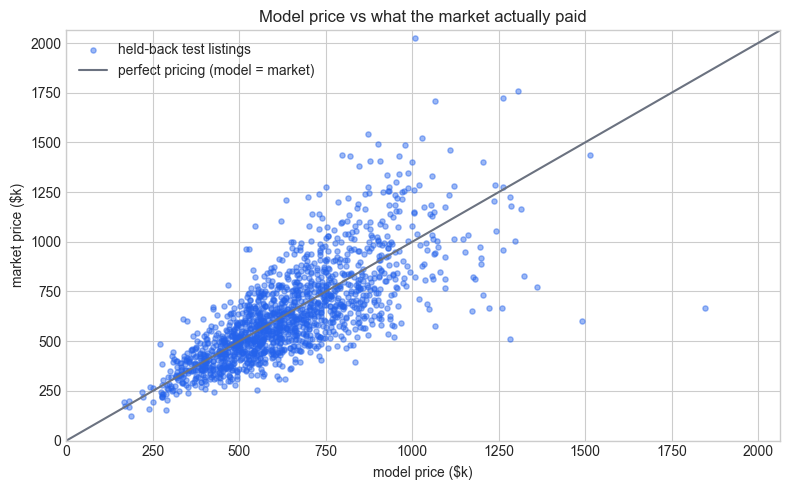

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred_test, y_test, s=14, alpha=0.45, color=BLUE, label="held-back test listings")
lims = [0.0, float(max(pred_test.max(), y_test.max())) * 1.02]
ax.plot(lims, lims, color=GRAY, linewidth=1.5, label="perfect pricing (model = market)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Model price vs what the market actually paid")
ax.set_xlabel("model price ($k)")
ax.set_ylabel("market price ($k)")
ax.legend()
plt.tight_layout()
plt.show()

The cloud hugs the gray diagonal, which is the picture of "works on average". Look at its shape, though: the spread around the diagonal fans out as prices grow — cheap flats sit tight to the line, expensive villas scatter hundreds of thousands of dollars either side. That fan is the simulator's deliberate bigger-homes-noisier-prices fact showing through, and it is a first hint that one fixed error bar can never describe every listing (notebook 05 takes that hint seriously). For a desk that *buys* at the model's price, the two sides of the diagonal are not symmetric business outcomes: a point above the line is a home the model underpriced (the seller declines, we lose a deal); a point below the line is a home the model overpriced (the seller signs immediately, and we overpay).

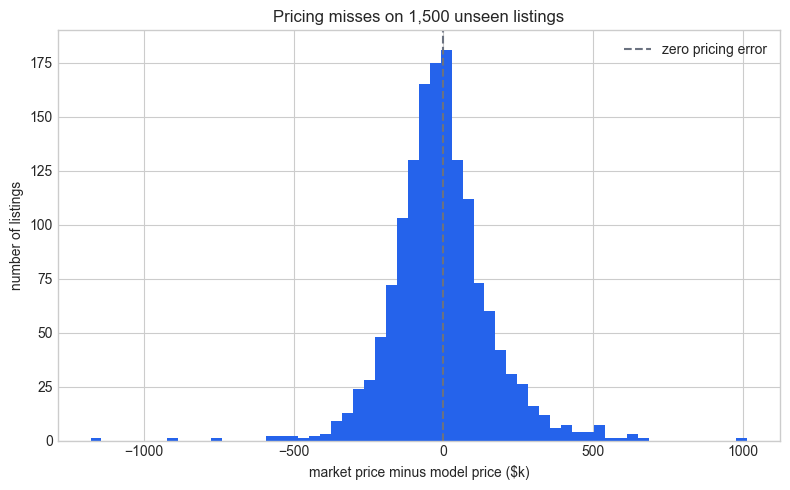

Misses beyond $100k: 670 listings (44.7%)
Misses beyond $200k: 257 listings (17.1%)
Largest single miss: $1,178.8k


In [6]:
errors = y_test - pred_test  # signed miss: positive = model underpriced the home

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(errors, bins=60, color=BLUE)
ax.axvline(0.0, color=GRAY, linestyle="--", linewidth=1.5, label="zero pricing error")
ax.set_title("Pricing misses on 1,500 unseen listings")
ax.set_xlabel("market price minus model price ($k)")
ax.set_ylabel("number of listings")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Misses beyond $100k: {(np.abs(errors) > 100).sum()} listings "
    f"({(np.abs(errors) > 100).mean():.1%})"
)
print(
    f"Misses beyond $200k: {(np.abs(errors) > 200).sum()} listings "
    f"({(np.abs(errors) > 200).mean():.1%})"
)
print(f"Largest single miss: ${np.abs(errors).max():,.1f}k")

This is the histogram the MAE was hiding. 670 of 1,500 listings — 44.7% — miss by more than \$100k. 257 listings (17.1%) miss by more than \$200k. The single worst miss is \$1,178.8k, on a model whose report card says "average error \$118k". Note also which tail hurts: the left tail is homes the model overpriced, the offers most likely to be accepted — the Zillow tail. The histogram does not mean the model is broken; a noisy market guarantees a spread of errors for any model. It means the *summary* was never going to carry the information the desk needs.

In [7]:
i_best = int(np.argmin(np.abs(errors)))
i_worst = int(np.argmax(np.abs(errors)))

def describe_listing(i, tag):
    # Reused below for the model's best and worst day - same printout, no cherry-typing.
    size, age, dist, cond = X_test[i]
    print(tag)
    print(
        f"  {size:.0f} m2 | {age:.0f} years old | {dist:.1f} km from center | "
        f"condition {cond:.0f}/5"
    )
    print(
        f"  model price ${pred_test[i]:,.1f}k | market price ${y_test[i]:,.1f}k | "
        f"miss ${errors[i]:+,.1f}k"
    )

describe_listing(i_best, "Listing A - the model's best day:")
describe_listing(i_worst, "Listing B - the model's worst day:")

Listing A - the model's best day:
  115 m2 | 46 years old | 16.5 km from center | condition 4/5
  model price $318.1k | market price $318.2k | miss $+0.1k
Listing B - the model's worst day:
  319 m2 | 0 years old | 2.7 km from center | condition 4/5
  model price $1,847.0k | market price $668.2k | miss $-1,178.8k


Listing A: a 115 m2, 46-year-old home far from the center; the model called the market price to within \$100. Listing B: a brand-new 319 m2 villa; the model said \$1,847.0k, the market said \$668.2k. Had the desk offered the model's number, Hearthstone would have overpaid by \$1,178.8k — the miss is bigger than the entire house. Yes, these are the two extremes of the histogram, but every listing in its tails is a real deal someone would have signed.

Here is the point of this whole section: the model produced both of those numbers *the same way*. Same `predict` call, same confident-looking single number, no flag, no wider font on the bad one. Point predictions are not wrong; they are silent about the one thing the desk trades on — how far off this number might be, on this house.

## 3. Homegrown uncertainty, attempt 1: plus-or-minus the MAE

The desk's first proposal is the one you will hear in every business review: "the average miss is \$118k, so quote every price as the model's number plus or minus \$118k." It sounds principled — the cushion comes from a measured error statistic, not from thin air.

Before running the check, try to answer one question about this recipe: what fraction of listings *should* land inside a plus-or-minus-MAE band? Take a moment. There is no way to know — the recipe never chose a fraction. That silence is the first sign something is off.

In [8]:
half_width = mae  # the desk's proposal: the average miss as the cushion

inside_mae_band = np.abs(errors) <= half_width
print(f"Recipe: model price +/- ${half_width:.1f}k")
print(f"Listings whose market price landed inside: {inside_mae_band.sum():,} of {len(y_test):,}")
print(f"Measured hit rate: {inside_mae_band.mean():.3f}")

Recipe: model price +/- $118.3k
Listings whose market price landed inside: 924 of 1,500
Measured hit rate: 0.616


The measured fraction is 0.616 — 924 of 1,500 listings. That fraction has a name we will use for the rest of the series: **coverage**, the fraction of listings whose true value falls inside the stated range. Coverage is the hit rate of an uncertainty claim, and it is measurable for any interval recipe, homegrown or principled, exactly the way we just did it.

Sit with the number for a second: 61.6%. Nobody chose it. It is not 90%, not 95%, not even a round number a stakeholder could repeat — it is an accident of this model's error distribution on this market, and it will drift silently every time the model is retrained or the market moves. Worse, the recipe has no knob: if the desk says "we need to be right 90% of the time," plus-or-minus-MAE has no input where 90% goes. An interval whose hit rate nobody chose and nobody checks is statistics theatre. One caution before we fix the knob problem: even a properly measured coverage is a batting average across many deals, not a probability about the single at-bat in front of you — notebook 03 makes precise what that distinction means and why it matters.

## 4. Homegrown uncertainty, attempt 2: quantiles of the training residuals

A smarter colleague now proposes the obvious upgrade: choose the hit rate *first*, then read the band off the model's own errors. Concretely: compute the model's **residuals** — for each listing, the signed miss, market price minus model price — on the data the model was fit to, take the 5th and 95th percentiles of those residuals, and attach that band to every prediction. By construction, 90% of *training* listings fall inside such a band. At last, a recipe with a dial that says 90 on it.

Meanwhile, in the same sprint, the team has been chasing a better report card and triples the boosting rounds from 100 to 300 — more rounds means the ensemble keeps fitting the training data harder. Two changes land at once. Watch closely.

In [9]:
model_boosted = GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_SEED)
model_boosted.fit(X_train, y_train)

for name, m in [("default (100 rounds)", model), ("boosted (300 rounds)", model_boosted)]:
    train_mae = mean_absolute_error(y_train, m.predict(X_train))
    test_mae = mean_absolute_error(y_test, m.predict(X_test))
    print(
        f"{name:22s} train MAE ${train_mae:6.1f}k | test MAE ${test_mae:6.1f}k | "
        f"gap ${test_mae - train_mae:5.1f}k"
    )

default (100 rounds)   train MAE $ 105.8k | test MAE $ 118.3k | gap $ 12.5k
boosted (300 rounds)   train MAE $  91.5k | test MAE $ 121.6k | gap $ 30.0k


One printout above deserves a careful reading before we build any band on top of it. The extra 200 rounds improved the *training* MAE from \$105.8k to \$91.5k — and nudged the *test* MAE the wrong way, from \$118.3k to \$121.6k. The new capacity was not spent learning the market; it was spent memorizing the training noise. The train-test gap widened from \$12.5k to \$30.0k. Keep that gap in mind: the residual band we are about to build sits entirely on the flattering side of it.

In [10]:
# The mistake, committed in full: measure residuals on the SAME data the model was fit to.
res_train_boosted = y_train - model_boosted.predict(X_train)
band_lo, band_hi = np.percentile(res_train_boosted, [5, 95])

pred_test_boosted = model_boosted.predict(X_test)
res_test_boosted = y_test - pred_test_boosted

inside_train = (res_train_boosted >= band_lo) & (res_train_boosted <= band_hi)
inside_test = (res_test_boosted >= band_lo) & (res_test_boosted <= band_hi)

assert abs(inside_train.mean() - 0.90) < 0.005, (
    "The band must catch ~90% of TRAINING residuals by construction - "
    "if this fires, the percentile call is broken, not the theory"
)

print(f"Band from training residuals: model price {band_lo:+.1f}k .. {band_hi:+.1f}k")
print(f"Hit rate on training listings: {inside_train.mean():.3f}  (by construction)")
print(f"Hit rate on fresh test listings: {inside_test.mean():.3f}  ({inside_test.sum()} of {len(y_test)})")
print(f"Miss budget at 10%: {int(0.10 * len(y_test))} listings | actual misses: {(~inside_test).sum()}")

# Same recipe on the gentler default model, for the interpretation below.
res_train_default = y_train - model.predict(X_train)
lo_d, hi_d = np.percentile(res_train_default, [5, 95])
inside_test_default = (errors >= lo_d) & (errors <= hi_d)
print(
    f"Same recipe on the default model: band {lo_d:+.1f}k .. {hi_d:+.1f}k, "
    f"test hit rate {inside_test_default.mean():.3f}"
)

Band from training residuals: model price -185.0k .. +211.5k
Hit rate on training listings: 0.900  (by construction)
Hit rate on fresh test listings: 0.811  (1216 of 1500)
Miss budget at 10%: 150 listings | actual misses: 284
Same recipe on the default model: band -215.7k .. +247.6k, test hit rate 0.871


This is the centerpiece failure of the notebook, so read the printout slowly. We chose 90%. On training data the band delivers 90.0% — of course it does; we built it from those very residuals. On fresh listings it delivers 81.1%: 284 misses where the budget allowed 150, nearly twice the agreed error rate. A desk pricing its walk-away risk at one-in-ten is actually running one-in-five.

The mechanism is plain: the boosted model has memorized part of the training noise, so its residuals on training data are optimistically small — and the 5th-to-95th band inherited exactly that optimism. Fresh listings got no such favor, so their residuals run systematically larger, and the band is too tight by precisely the amount of the model's self-flattery. This is field guide §2, the single most tempting shortcut in this subject: never measure your uncertainty on data the model has already seen.

One more subtlety: the last line shows the same recipe on the gentler default model, which lands at 87.1% — closer to the promise, but still below it and still silent about being below it. The bias always points the same direction (down); only its size varies with how hard the model overfits, and you cannot read that size off the training data. Nothing in this pipeline raised an exception. The backtest said 90.0%. Only the held-back listings — data with no stake in flattering the model — told the truth.

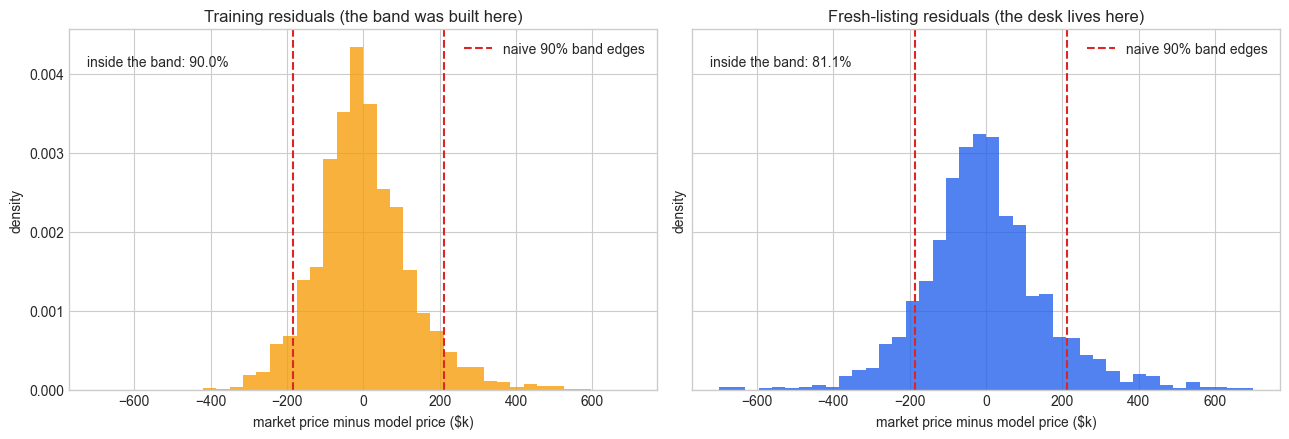

Test misses below the band: 157 | above the band: 127
Residuals beyond the plotted +-$700k range - training: 0, test: 5


In [11]:
bins = np.linspace(-700, 700, 41)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
panels = [
    (axes[0], res_train_boosted, AMBER, "Training residuals (the band was built here)", inside_train.mean()),
    (axes[1], res_test_boosted, BLUE, "Fresh-listing residuals (the desk lives here)", inside_test.mean()),
]
for ax, res, color, title, rate in panels:
    ax.hist(res, bins=bins, density=True, color=color, alpha=0.8)
    ax.axvline(band_lo, color=RED, linestyle="--", linewidth=1.5, label="naive 90% band edges")
    ax.axvline(band_hi, color=RED, linestyle="--", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("market price minus model price ($k)")
    ax.set_ylabel("density")
    ax.text(0.03, 0.93, f"inside the band: {rate:.1%}", transform=ax.transAxes, va="top")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(
    f"Test misses below the band: {(res_test_boosted < band_lo).sum()} | "
    f"above the band: {(res_test_boosted > band_hi).sum()}"
)
print(
    f"Residuals beyond the plotted +-$700k range - "
    f"training: {(np.abs(res_train_boosted) > 700).sum()}, test: {(np.abs(res_test_boosted) > 700).sum()}"
)

The two panels are the same model scored on two different worlds. The amber training residuals sit tall and narrow, and the red dashed edges clip exactly 5% off each tail — 90.0% inside, by construction. The blue fresh-listing residuals are visibly wider in both directions, so the same red edges now leave 18.9% of listings outside (157 below the band, 127 above). Five test listings miss by more than \$700k and do not even fit on the plotted axis; no training listing does. The lesson generalizes beyond percentile bands: *any* threshold, cushion, or error bar tuned on data the model has already seen inherits the model's optimism about itself.

## 5. What we actually want

Both homegrown attempts failed in instructive ways: attempt 1 never let us choose an error rate, and attempt 2 let us choose one and then quietly broke the promise. So let us write down the contract an honest method would have to sign.

First, we pick the error budget in advance: **alpha**, the fraction of deals we agree we are allowed to miss. The desk and the risk committee settle on alpha = 0.10 — a 90% target. Then we demand a recipe that turns every model price into a **prediction interval** — a per-listing range of prices — such that:

- *at least 90% of future listings' true prices land inside their intervals* — guaranteed **by construction**, not measured after the fact and hoped stable;
- the guarantee holds **for any model** — the overfit 300-round model from section 4 included, because uncertainty tooling that only works for well-behaved models protects you exactly when you least need it;
- it holds **in finite samples** — with the few thousand listings we actually have, not "asymptotically" with data we will never collect.

Two refinements complete the wish list. The classic way to picture the first: predicting where a target sits in a field (the image is from Vovk, Gammerman and Shafer, the founders of the method notebook 02 introduces). A casual 80% blob is small; the confident 95% blob surrounds it; the highly-confident 99% blob is wider still — and the 100% region is the entire field, which is why demanding certainty yields a useless answer. Confidence buys size, honestly and visibly. Second, width should track difficulty: a 60 m2 flat deserves a narrow interval and a 300 m2 villa a wide one — our simulator guarantees it, and section 2's fan-shaped scatter showed it. An interval that is honest about a hard listing by being *wide* is the walk-away signal the desk asked for on page one (notebook 05 builds exactly this).

Does statistical theory not already offer guarantees? It does — and the founders of the field note drily that classical learning-theory error bounds, applied at realistic dataset sizes, are "often greater than 1": bounds that are technically true and totally useless. We are after something humbler and sharper: a guarantee that is honest and *checkable*, on our own held-back listings, the same way we just audited attempts 1 and 2. And because a wide-enough band can trivially hit any coverage target, an honest report always states coverage *and* width together (field guide §5) — coverage is the promise kept, width is the usefulness earned.

Here is the whole notebook as one table:

| What you report | What it promises | Where it breaks |
|---|---|---|
| Point prediction ("worth \$412k") | Nothing — a best guess with no error statement | Listing B: model said \$1,847k, market said \$668k, same confident printout |
| Model price ± MAE | A range with an unknown hit rate | Measured coverage 61.6% — an accident nobody chose, with no knob to change it |
| 5th-95th percentiles of training residuals | 90% hit rate, on data the model memorized | 81.1% on fresh listings; worse the harder the model overfits; fails silently |
| Prediction interval with guaranteed coverage | At least 90% of future listings inside, by construction, for any model | Needs one honest data split and one assumption about the data — notebook 02 names both |

## 6. Common mistakes to avoid

1. **Answering a per-deal risk question with an average.** MAE \$118.3k and R2 0.545 describe 1,500 listings at once; the desk signs them one at a time, and 17.1% of ours missed by more than \$200k.
2. **Shipping plus-or-minus-*something* bands without measuring their coverage.** Ours covered 61.6% — a number nobody chose and nobody would have noticed drifting after the next retrain.
3. **Measuring your uncertainty on data the model trained on.** The backtest said 90.0%, fresh listings said 81.1%. The failure raises no exception and shows up only where it is most expensive — in production (field guide §2).
4. **Trying to fix uncertainty by making the model stronger.** The 300-round model had a better training MAE than the default one, and its training-residual band was both narrower and *more* wrong (81.1% vs 87.1%). Model capacity and honest uncertainty are different axes.
5. **Assuming errors are symmetric and thin-tailed.** Our residual band came out asymmetric (−\$185.0k to +\$211.5k), and the worst miss was \$1,178.8k on a \$668.2k house. Recipes like "±1.96 standard deviations" import a normality assumption nobody audited.
6. **Trusting a hit rate no one is allowed to choose.** If the recipe has no place to write alpha, whatever coverage you observe is a coincidence, not a policy.

## 7. What to say in the business review

**Strong version**

> On 1,500 held-back listings, the pricing model's average miss is \$118k — but one listing in six misses by more than \$200k, and the worst single miss was \$1.18M on a \$668k house. Both of our in-house interval recipes failed their audit: plus-or-minus MAE covered 61.6% of listings, a hit rate nobody chose, and the training-residual band promised 90% but delivered 81.1% on fresh deals. Until every offer carries an interval with an error rate we fix in advance and can verify on held-back data, the desk cannot bound its exposure per deal. That interval is the next deliverable.

**Weak version**

> The model is usually within about \$120k, and we've added 90% error bars based on its historical residuals, so the desk can offer with confidence.

The weak version quotes an average as if it were a bound, and cites a promise ("90%") that our own measurement already contradicts at 81.1%. The strong version states measured numbers a stakeholder can check, names the failure honestly, and commits to a deliverable with a verifiable property — which is the only kind of uncertainty statement worth putting in front of people who sign offer letters.

### The one-line summary

The point prediction hid the spread; the spread is where the desk's money lives. Plus-or-minus-MAE gave us an interval with an accidental hit rate, and training-residual quantiles gave us a chosen hit rate that quietly broke on contact with fresh data — 90 promised, 81.1 delivered. What we wrote down instead is a contract: an error budget alpha chosen in advance, intervals that keep it for any model in finite samples, and a width that tells the desk when to walk away. Notebook 02 signs that contract in about fifteen lines of numpy — split conformal prediction — and proves the 90% holds on the very market that just embarrassed every recipe in this notebook.

A single number is an opinion; a calibrated range is a commitment.